In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sympy as sp
import scipy as sy
from scipy.integrate import odeint
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root

### $\dot{\rho_X}=-3H(1+w)(\rho_X -\rho_\Lambda)+Q$ 
w is the affine parameter and Q the interaction term. $Q=qH(\rho_X-\rho_\Lambda)$ q is interaction strength

### $\dot{\rho_m}=-3H\rho_m-Q$

This is an affine interacting model of DE that has density $\rho_X=\rho_{dynamic}+\rho_\Lambda =(1-\alpha)\rho_X +\alpha \rho_X $ where the equation of state (EoS) above only evolves $\rho_{dyn}$. We find that the EoS of dark energy parameter $w_X=w-(1+w)\frac{\rho_\Lambda}{\rho_X}$. But we want to study the interacting EoS $w_{int}$ instead.
From 
$\dot{\rho_X}=-3H(1+w)(\rho_X -\rho_\Lambda)+Q = -3H(1+w_{int})\rho_X$
we find that:

### $w_{int} = -1 +(1+w)\frac{(\rho_X-\rho_\Lambda)}{\rho_\Lambda} -\frac{q(\rho_X -\rho_m)}{3\rho_X} = -1 +(1+w)\frac{x}{x+z} -\frac{q(x+z-y)}{3(x+z)} $

using dimensionless variables $x=\Omega_{dyn}=\rho_{dyn}/3H^2$, $y=\Omega_{m}=\rho_{m}/3H^2$ and $z=\Omega_{\Lambda}=\rho_{\Lambda}/3H^2$ and in N=ln(a) time not t time where dt=NdN
##### $    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R ~~(DE) $
##### $    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R  ~~(DM) $
##### $   dz= 3*z*x*(1+w) +3*y*z+ 4*z*R ~~(constant~~~DE)$
##### $   dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2 ~~ (radiation)$

early time vals: 0.007852875142302838 0.4477516043377268 2.6236698755769058e-12 0.5443955205173535 simulationTime last: -8.0
wint early time: -0.06637437226788367
term 2 and term 3 at late times: 1.666209281983117e-11 0.9336256277154542
wint_value -0.10946804444622515
y is largest at: 159 0.9775605241100653
values at largest y 0.018901553265803797 0.977496513523638 7.359996925401492e-05 0.0035285266426832683 N= -2.4529058116232463
wint at y largest is: -0.1578968662160748


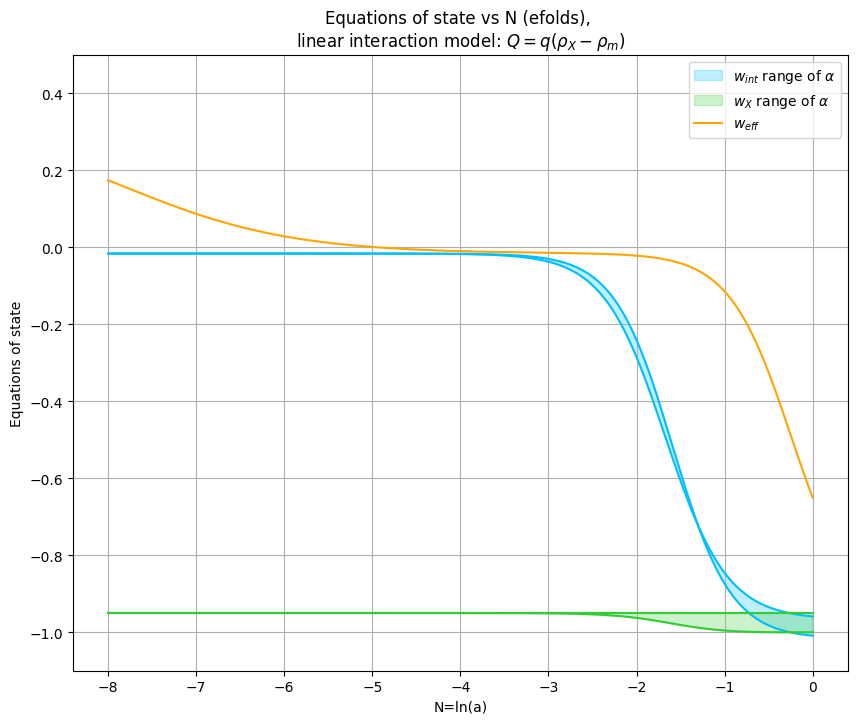

In [29]:
w,q=-0.95,0.05
alpha = np.linspace(0,1,50) # the fraction of the total DE that is affine or constant.
a=0.05
simulationTime=np.linspace(0,-8,500)
ICs=[0.685,0.315,9e-5]# [OmegaDE,OmegaM,OmegaR] where OmegaDE is total dyn and lambda x+z.
# using PLANCK 2018  ICs from the paper and refernece in text.
Omega_DE=0.685
Omega_m=0.315
Omega_R=9e-5
x0 = (1 - a) * Omega_DE
y0 = Omega_m
z0 = a * Omega_DE
R0 = Omega_R

def system_linear(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]



def vary_alpha(a,model,Q):
    x0 = (1 - a) * Omega_DE
    y0 = Omega_m
    z0 = a * Omega_DE
    R0 = Omega_R
    sol = solve_ivp(model, [0,-8], [x0,y0,z0,R0] ,method='RK45',t_eval=simulationTime,rtol=1e-20,atol=1e-20)
    x, y, z, R = sol.y
    Q = Q(x, y, z, R)
    denom_DE = x + z + 1e-20

    wX = w-(1+w)*z*(x + y + z + R)/((x+z)*(x + y + z + R))
    weff = (w*x - z + (1/3)*R) / (x + z + y + R + 1e-20)
    wint = -1 + (1+w)*x*(x + y + z + R)/((x+z)*(x + y + z + R)) -Q/(3*(x+z)*(x + y + z + R))
    return wint, wX, weff

def Q_linear(x, y, z, R):
    return q*(x + z - y)


sol0 = solve_ivp(system_linear, [0,-8], [x0,y0,z0,R0] ,method='RK45',t_eval=simulationTime,rtol=1e-20,atol=1e-20)
x_lin,y_lin,z_lin,R_lin = sol0.y



#linear
plt.figure(figsize=(10,8))
wX_0=(w*x_lin -z_lin)/(x_lin+z_lin+1e-9)
weff_0=(w*x_lin -z_lin +1/3 *R_lin)/(x_lin+z_lin+y_lin+R_lin+1e-9)



wint0, wX0, weff0 = vary_alpha(a=0, model=system_linear,Q=Q_linear)
wint1, wX1, weff1 = vary_alpha(a=1,model=system_linear ,Q=Q_linear)
plt.fill_between(simulationTime, np.minimum(wint0, wint1), np.maximum(wint0, wint1),alpha=0.25, label=r'$w_{int}$ range of $\alpha$',color='deepskyblue')
plt.plot(simulationTime,wint0,c='deepskyblue')
plt.plot(simulationTime,wint1,c='deepskyblue')
plt.fill_between(simulationTime, np.minimum(wX0, wX1), np.maximum(wX0, wX1),alpha=0.25, label=r'$w_{X}$ range of $\alpha$',color='limegreen')
plt.plot(simulationTime,wX0,c='limegreen')
plt.plot(simulationTime,wX1,c='limegreen')

plt.plot(simulationTime,weff0,label=r'$w_{eff}$',color='orange')
plt.legend()
plt.title(f'Equations of state vs N (efolds), \n' r'linear interaction model: $Q={q (\rho_X-\rho_m) }$')
plt.xlabel('N=ln(a)')
plt.ylabel('Equations of state')
plt.ylim(-1.1,0.5)
#plt.xlim(-8,0)
plt.grid()


print('early time vals:',x_lin[-1],y_lin[-1],z_lin[-1],R_lin[-1],'simulationTime last:',simulationTime[-1])
test_lin = 1-x_lin[-1]-y_lin[-1]-R_lin[-1]
wint_last = -1+(1+w)*test_lin/(x_lin[-1]+test_lin) -1/(3*(x_lin[-1]+test_lin)) *q*(x_lin[-1]+test_lin-y_lin[-1])
print('wint early time:', wint_last)
term2 = (1+w)*test_lin/(x_lin[-1]+test_lin)
term3 = -1/(3*(x_lin[-1]+test_lin)) *q*(x_lin[-1]+test_lin-y_lin[-1])
print('term 2 and term 3 at late times:',term2,term3)

idx = np.argmin(np.abs(simulationTime - (-2.45)))
wint_value = wint0[idx]
print('wint_value', wint_value)

for i in range(len(y_lin)):
    if y_lin[i]==np.max(y_lin):
        print('y is largest at:',i, y_lin[i])
print('values at largest y',x_lin[153],y_lin[153],z_lin[153],R_lin[153],'N=',simulationTime[153])
wint_ylarge = -1+(1+w)*z_lin[153]/(x_lin[153]+z_lin[153]) -1/(3*(x_lin[153]+z_lin[153])) *q*(x_lin[153]+z_lin[153]-y_lin[153])
print('wint at y largest is:',wint_ylarge)


Our affine model is not supposed to behave like ordinary quintessence.
The constant Λ-sector stabilises the DE density and softens singular behaviour.
So the fact that:
w_int plateaus, remains finite, and avoids huge divergence, is actually consistent with the affine structure.

That is likely worth discussing explicitly as a distinction between: interacting quintessence, and interacting affine dark fluids.



#### At early times in the limit $\rho_m/\rho_X>>1$, we find that the interaction term $Q=qH(\rho_X-\rho_m)$. Therefore the interaction equation of state becomes:
$w_{int} = -1 +(1+w)\frac{x}{x+z} +\frac{q(y)}{\sim 0} $

therefore, whilst the second term $\approx 0$ the last term tends to $\infty$ because is divided by 0

<>:141: SyntaxWarning: invalid escape sequence '\O'
<>:141: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_3411/3679652847.py:141: SyntaxWarning: invalid escape sequence '\O'
  plt.title(f'Plot of energy density fractions $\Omega$ for dynamical DE, $\Lambda$-like DE, \n' r'DM and radiation for all interaction models of Q',fontsize=18)


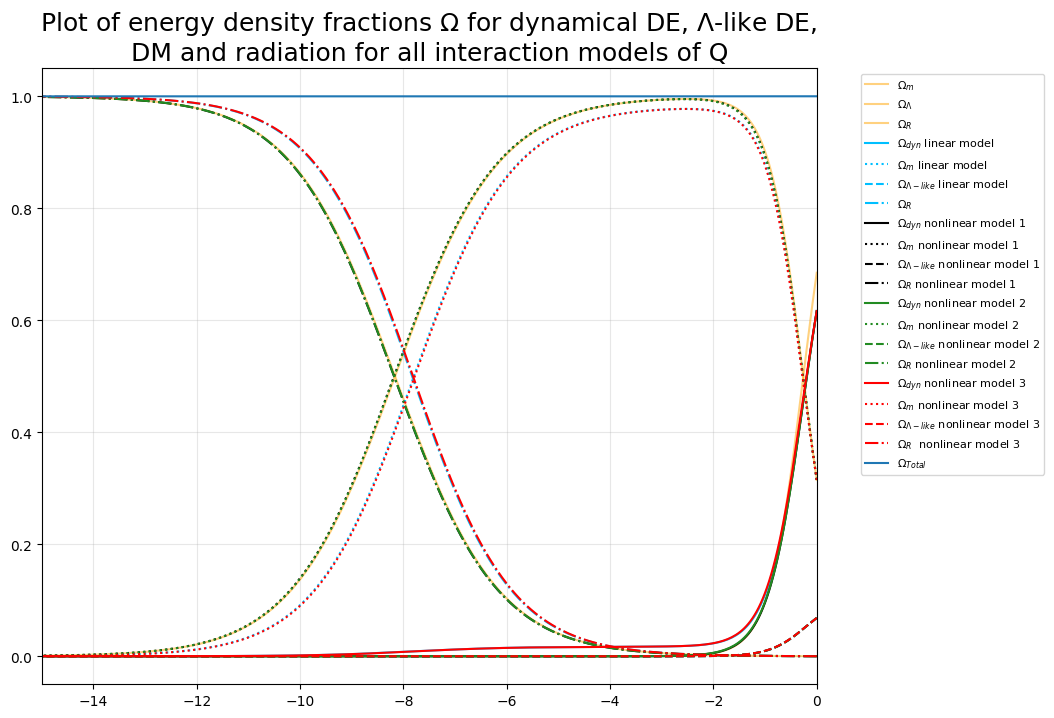

In [3]:
#weff for all different models

w,q=-0.95,0.05
def lamCDM_system(t,vars):
    y,z,R=vars
    #z=1-y-R
    dy=3*(y**2-y)+4*R*y
    dR = 4*R**2+3*R*y-4*R
    dz=3*y*z+4*R*z

    return [dy,dz,dR]

#   instead of using alpha as variable, using alpha as 0.5 to show even split between dynamical (alpha=0) and constant (alpha =1)
def system_linear(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]

def system_nonlinear1(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+(q*(x+z)*y)/(1-R+1e-6)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -(q*(x+z)*y)/(1-R+1e-6)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]

def system_nonlinear2(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*((x+z)**2)/(1-R+1e-6)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*((x+z)**2)/(1-R+1e-6)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]

def system_nonlinear3(t,vars):
    x,y,z,R=vars
    # Avoid numerical issues
    denom = max(1e-12, 1 - R)   # x+y+z = 1-R
    Q = q * y**2 / denom
    dx = -3*(1 + w)*x - Q +3*x*y+ 3*x**2*(1+w)+4*R*x
    dy =  -3*y + Q + 3*y**2 +3*y*x*(1+w)+4*y*R
    dz = 3*z*y +(1+w)*x*3*z+4*R*z
    dR =  -4*R + 3*R*y+3*R*x*(1+w)+4*R**2

    return [dx,dy,dz,dR]


simulationTime=np.linspace(0,-20,500)
a=0.1
ICs=[(1-a)*0.685,0.315,a*0.685,9e-5] #DE=0.685 but alpha =0.5 so 0.3425
sol_lam=solve_ivp(lamCDM_system,[0,-20],np.array([0.315,0.685,9e-5]),t_eval=simulationTime,rtol=1e-6,atol=1e-6)
sol0=solve_ivp(system_linear,[0,-20],ICs,t_eval=simulationTime,rtol=1e-6,atol=1e-6)
sol1=solve_ivp(system_nonlinear1,[0,-20],ICs,t_eval=simulationTime,rtol=1e-6,atol=1e-6)
sol2=solve_ivp(system_nonlinear2,[0,-20],ICs,t_eval=simulationTime,rtol=1e-6,atol=1e-6)
sol3=solve_ivp(system_nonlinear3,[0,-20],ICs,t_eval=simulationTime,rtol=1e-6,atol=1e-6)



ys_lam,zs_lam,Rs_lam = [],[],[]
ys_lam=sol_lam.y[0]
Rs_lam = sol_lam.y[2]
zs_lam=sol_lam.y[1]
total_lam =  ys_lam + zs_lam + Rs_lam

xs_lin,ys_lin,zs_lin,Rs_lin = [],[],[],[]
xs_lin=sol0.y[0]
ys_lin=sol0.y[1]
zs_lin=sol0.y[2]
Rs_lin = sol0.y[3]
total_lin = xs_lin + ys_lin + zs_lin + Rs_lin

xs_non1,ys_non1,zs_non1,Rs_non1 = [],[],[],[]
xs_non1=sol1.y[0]
ys_non1=sol1.y[1]
zs_non1=sol1.y[2]
Rs_non1 =sol1.y[3]
total_non1 = xs_non1 + ys_non1 + zs_non1 + Rs_non1

xs_non2,ys_non2,zs_non2,Rs_non2 = [],[],[],[]
xs_non2=sol2.y[0]
ys_non2=sol2.y[1]
zs_non2=sol2.y[2]
Rs_non2 =sol2.y[3]
total_non2 = xs_non2 + ys_non2 + zs_non2 + Rs_non2

xs_non3,ys_non3,zs_non3,Rs_non3 = [],[],[],[]
xs_non3=sol3.y[0]
ys_non3=sol3.y[1]
zs_non3=sol3.y[2]
Rs_non3 =sol3.y[3]
total_non3 = xs_non3 + ys_non3 + zs_non3 + Rs_non3

plt.figure(figsize=(10,8))
plt.plot(simulationTime,ys_lam,label=r'$\Omega_{m}$',c='orange',alpha=0.5)
plt.plot(simulationTime,zs_lam,label=r'$\Omega_{\Lambda}$',c='orange',alpha=0.5)
plt.plot(simulationTime,Rs_lam,label=r'$\Omega_{R}$',c='orange',alpha=0.5)



#label=r'$x=\Omega_{dyn}$ (purely dynamical DE)',color='deepskyblue',linestyle=':'
plt.plot(simulationTime, xs_lin,label=r'$\Omega_{dyn}$ linear model',c='deepskyblue')
plt.plot(simulationTime,ys_lin,label=r'$\Omega_{m}$ linear model',c='deepskyblue',linestyle=':')
plt.plot(simulationTime,zs_lin,label=r'$\Omega_{\Lambda -like}$ linear model',c='deepskyblue',linestyle='--')
plt.plot(simulationTime,Rs_lin,label=r'$\Omega_{R}$',c='deepskyblue',linestyle='-.')




#label=r'$x=\Omega_{dyn}$ (purely dynamical DE)',color='deepskyblue',linestyle=':'
plt.plot(simulationTime, xs_non1,label=r'$\Omega_{dyn}$ nonlinear model 1',c='k')
plt.plot(simulationTime,ys_non1,label=r'$\Omega_{m}$ nonlinear model 1',c='k',linestyle=':')
plt.plot(simulationTime,zs_non1,label=r'$\Omega_{\Lambda -like}$ nonlinear model 1',c='k',linestyle='--')
plt.plot(simulationTime,Rs_non1,label=r'$\Omega_{R}$ nonlinear model 1',c='k',linestyle='-.')




#label=r'$x=\Omega_{dyn}$ (purely dynamical DE)',color='deepskyblue',linestyle=':'
plt.plot(simulationTime, xs_non2,label=r'$\Omega_{dyn}$ nonlinear model 2',c='forestgreen')
plt.plot(simulationTime,ys_non2,label=r'$\Omega_{m}$ nonlinear model 2',c='forestgreen',linestyle=':')
plt.plot(simulationTime,zs_non2,label=r'$\Omega_{\Lambda -like}$ nonlinear model 2',c='forestgreen',linestyle='--')
plt.plot(simulationTime,Rs_non2,label=r'$\Omega_{R}$ nonlinear model 2',c='forestgreen',linestyle='-.')




#label=r'$x=\Omega_{dyn}$ (purely dynamical DE)',color='deepskyblue',linestyle=':'
plt.plot(simulationTime, xs_non3,label=r'$\Omega_{dyn}$ nonlinear model 3',c='r')
plt.plot(simulationTime,ys_non3,label=r'$\Omega_{m}$ nonlinear model 3',c='r',linestyle=':')
plt.plot(simulationTime,zs_non3,label=r'$\Omega_{\Lambda -like}$ nonlinear model 3',c='r',linestyle='--')
plt.plot(simulationTime,Rs_non3,label=r'$\Omega_{R}$  nonlinear model 3',c='r',linestyle='-.')
plt.plot(simulationTime, total_non3,label=r'$\Omega_{Total}$')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.title(f'Plot of energy density fractions $\Omega$ for dynamical DE, $\Lambda$-like DE, \n' r'DM and radiation for all interaction models of Q',fontsize=18)
plt.xlim(-15,0)
plt.grid(True, alpha=0.3)
plt.show()



early time vals: 0.007852875142302838 0.4477516043377268 2.6236698755769058e-12 0.5443955205173535 simulationTime last: -8.0
wint early time: -0.06637437226788367
term 2 and term 3 at late times: 1.666209281983117e-11 0.9336256277154542
wint_value -0.10948262389635333
y is largest at: 159 0.9775605241100653
values at largest y 0.018901553265803797 0.977496513523638 7.359996925401492e-05 0.0035285266426832683 N= -2.4529058116232463
wint at y largest is: -0.1578968662160748


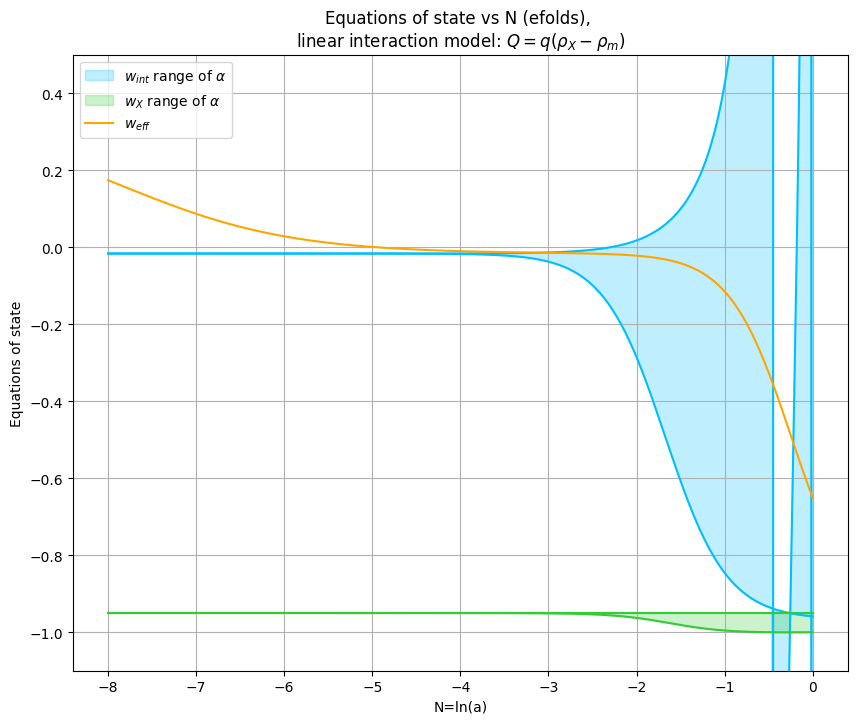

In [31]:
w,q=-0.95,0.05
simulationTime=np.linspace(0,-8,500)
ICs=[0.685,0.315,9e-5]# [OmegaDE,OmegaM,OmegaR] where OmegaDE is total dyn and lambda x+z.
# using PLANCK 2018  ICs from the paper and refernece in text.
Omega_DE=0.685
Omega_m=0.315
Omega_R=9e-5


def system_linear(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]



def vary_alpha(a,model,Q):
    x0 = (1 - a) * Omega_DE
    y0 = Omega_m
    z0 = a * Omega_DE
    R0 = Omega_R
    sol = solve_ivp(model, [0,-8], [x0,y0,z0,R0] ,method='RK45',t_eval=simulationTime,rtol=1e-20,atol=1e-20)
    x, y, z, R = sol.y
    Q = Q(x, y, z, R)
    denom_DE = x + z + 1e-20

    wX = w-(1+w)*z*(x + y + z + R)/((x+z)*(x + y + z + R))
    weff = (w*x - z + (1/3)*R) / (x + z + y + R + 1e-20)
    wint = w-Q/(3*x+ 1e-6)
    return wint, wX, weff

def Q_linear(x, y, z, R):
    return q*(x + z - y)


sol0 = solve_ivp(system_linear, [0,-8], [x0,y0,z0,R0] ,method='RK45',t_eval=simulationTime,rtol=1e-20,atol=1e-20)
x_lin,y_lin,z_lin,R_lin = sol0.y



#linear
plt.figure(figsize=(10,8))
wX_0=(w*x_lin -z_lin)/(x_lin+z_lin+1e-9)
weff_0=(w*x_lin -z_lin +1/3 *R_lin)/(x_lin+z_lin+y_lin+R_lin+1e-9)



wint0, wX0, weff0 = vary_alpha(a=0, model=system_linear,Q=Q_linear)
wint1, wX1, weff1 = vary_alpha(a=1,model=system_linear ,Q=Q_linear)
plt.fill_between(simulationTime, np.minimum(wint0, wint1), np.maximum(wint0, wint1),alpha=0.25, label=r'$w_{int}$ range of $\alpha$',color='deepskyblue')
plt.plot(simulationTime,wint0,c='deepskyblue')
plt.plot(simulationTime,wint1,c='deepskyblue')
plt.fill_between(simulationTime, np.minimum(wX0, wX1), np.maximum(wX0, wX1),alpha=0.25, label=r'$w_{X}$ range of $\alpha$',color='limegreen')
plt.plot(simulationTime,wX0,c='limegreen')
plt.plot(simulationTime,wX1,c='limegreen')

plt.plot(simulationTime,weff0,label=r'$w_{eff}$',color='orange')
plt.legend()
plt.title(f'Equations of state vs N (efolds), \n' r'linear interaction model: $Q={q (\rho_X-\rho_m) }$')
plt.xlabel('N=ln(a)')
plt.ylabel('Equations of state')
plt.ylim(-1.1,0.5)
#plt.xlim(-8,0)
plt.grid()


print('early time vals:',x_lin[-1],y_lin[-1],z_lin[-1],R_lin[-1],'simulationTime last:',simulationTime[-1])
test_lin = 1-x_lin[-1]-y_lin[-1]-R_lin[-1]
wint_last = -1+(1+w)*test_lin/(x_lin[-1]+test_lin) -1/(3*(x_lin[-1]+test_lin)) *q*(x_lin[-1]+test_lin-y_lin[-1])
print('wint early time:', wint_last)
term2 = (1+w)*test_lin/(x_lin[-1]+test_lin)
term3 = -1/(3*(x_lin[-1]+test_lin)) *q*(x_lin[-1]+test_lin-y_lin[-1])
print('term 2 and term 3 at late times:',term2,term3)

idx = np.argmin(np.abs(simulationTime - (-2.45)))
wint_value = wint0[idx]
print('wint_value', wint_value)

for i in range(len(y_lin)):
    if y_lin[i]==np.max(y_lin):
        print('y is largest at:',i, y_lin[i])
print('values at largest y',x_lin[153],y_lin[153],z_lin[153],R_lin[153],'N=',simulationTime[153])
wint_ylarge = -1+(1+w)*z_lin[153]/(x_lin[153]+z_lin[153]) -1/(3*(x_lin[153]+z_lin[153])) *q*(x_lin[153]+z_lin[153]-y_lin[153])
print('wint at y largest is:',wint_ylarge)


x is smallest at: 17 0.0006129773752228886 -0.2725450901803607
z is smallest at: 499 9.745505903932284e-11 -8.0


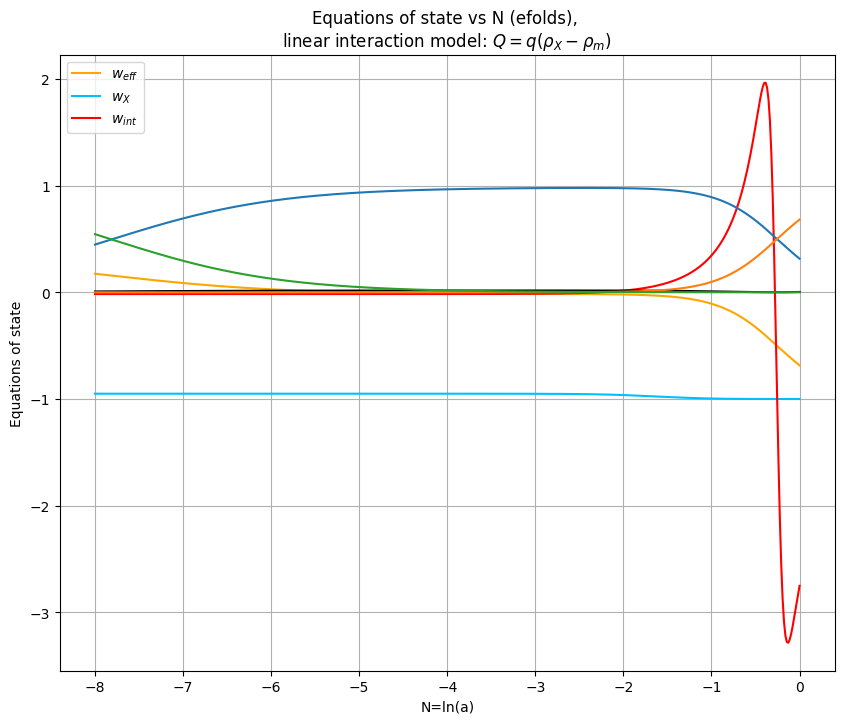

In [6]:
w,q=-0.95,0.05
simulationTime=np.linspace(0,-8,500)
ICs=[0.685,0.315,9e-5]# [OmegaDE,OmegaM,OmegaR] where OmegaDE is total dyn and lambda x+z.
# using PLANCK 2018  ICs from the paper and refernece in text.
Omega_DE=0.685
Omega_m=0.315
Omega_R=9e-5


def system_linear(t,vars):
    x,y,z,R=vars
    dx= 3*(1+w)*(x**2-x)+3*x*y+q*(x-y+z)+4*x*R #dynamic evolving DE
    dy=3*(y**2-y)+3*x*y*(1+w) -q*(x-y+z)+4*y*R #dynamic DM
    dz= 3*z*x*(1+w) +3*y*z+ 4*z*R
    dR = -4*R+(1+w)*3*x*R +3*y*R+4*R**2
    #   to plot standard Lambda CDM, set q=0, w=-1 and get rid of xR,yR and R^2 terms. 
    return [dx,dy,dz,dR]


alpha=0.995
sol0 = solve_ivp(system_linear, [0,-8], [(1-alpha)*Omega_DE,Omega_m,alpha*Omega_DE,Omega_R] ,method='RK45',t_eval=simulationTime,rtol=1e-6,atol=1e-6)
x_lin,y_lin,z_lin,R_lin = sol0.y



#linear
plt.figure(figsize=(10,8))
wX_0=(w*x_lin -z_lin)/(x_lin+z_lin+1e-9)
weff_0=(w*x_lin -z_lin +1/3 *R_lin)/(x_lin+z_lin+y_lin+R_lin+1e-9)
wint = w-(q*(x_lin + z_lin - y_lin))/(3*x_lin+1e-9)


plt.plot(simulationTime,weff_0,label=r'$w_{eff}$',color='orange')
plt.plot(simulationTime,wX_0,label=r'$w_{X}$',color='deepskyblue')
plt.plot(simulationTime,wint,label=r'$w_{int}$',color='red')
plt.legend()
plt.title(f'Equations of state vs N (efolds), \n' r'linear interaction model: $Q={q (\rho_X-\rho_m) }$')
plt.xlabel('N=ln(a)')
plt.ylabel('Equations of state')
#plt.ylim(-1.1,1.1)
#plt.xlim(-8,0)
plt.grid()

plt.plot(simulationTime,x_lin,c='k')
plt.plot(simulationTime,y_lin)
plt.plot(simulationTime,z_lin)
plt.plot(simulationTime,R_lin)

for i in range(len(x_lin)):
    if x_lin[i]==np.min(x_lin):
        print('x is smallest at:',i, x_lin[i],simulationTime[i])
for i in range(len(z_lin)):
    if z_lin[i]==np.min(z_lin):
        print('z is smallest at:',i, z_lin[i],simulationTime[i])
